In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sys
sys.path.append('../../')
from tools.plot_utils import (
    create_figure, 
    style_axes, 
    apply_color_palette, 
    plot_line,
    set_publication_style,
    save_figure
)

ModuleNotFoundError: No module named 'tools.plot_utils'

In [ ]:
df = pd.read_csv("data/consolidated.csv")

/tmp/ipykernel_1133180/2813983919.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_df['relative_prefill_time_s'] = sim_df['prefill_time_s'] / sim_baseline_time
/tmp/ipykernel_1133180/2813983919.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df['relative_prefill_time_s'] = real_df['prefill_time_s'] / real_baseline_time
/tmp/ipykernel_1133180/2813983919.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

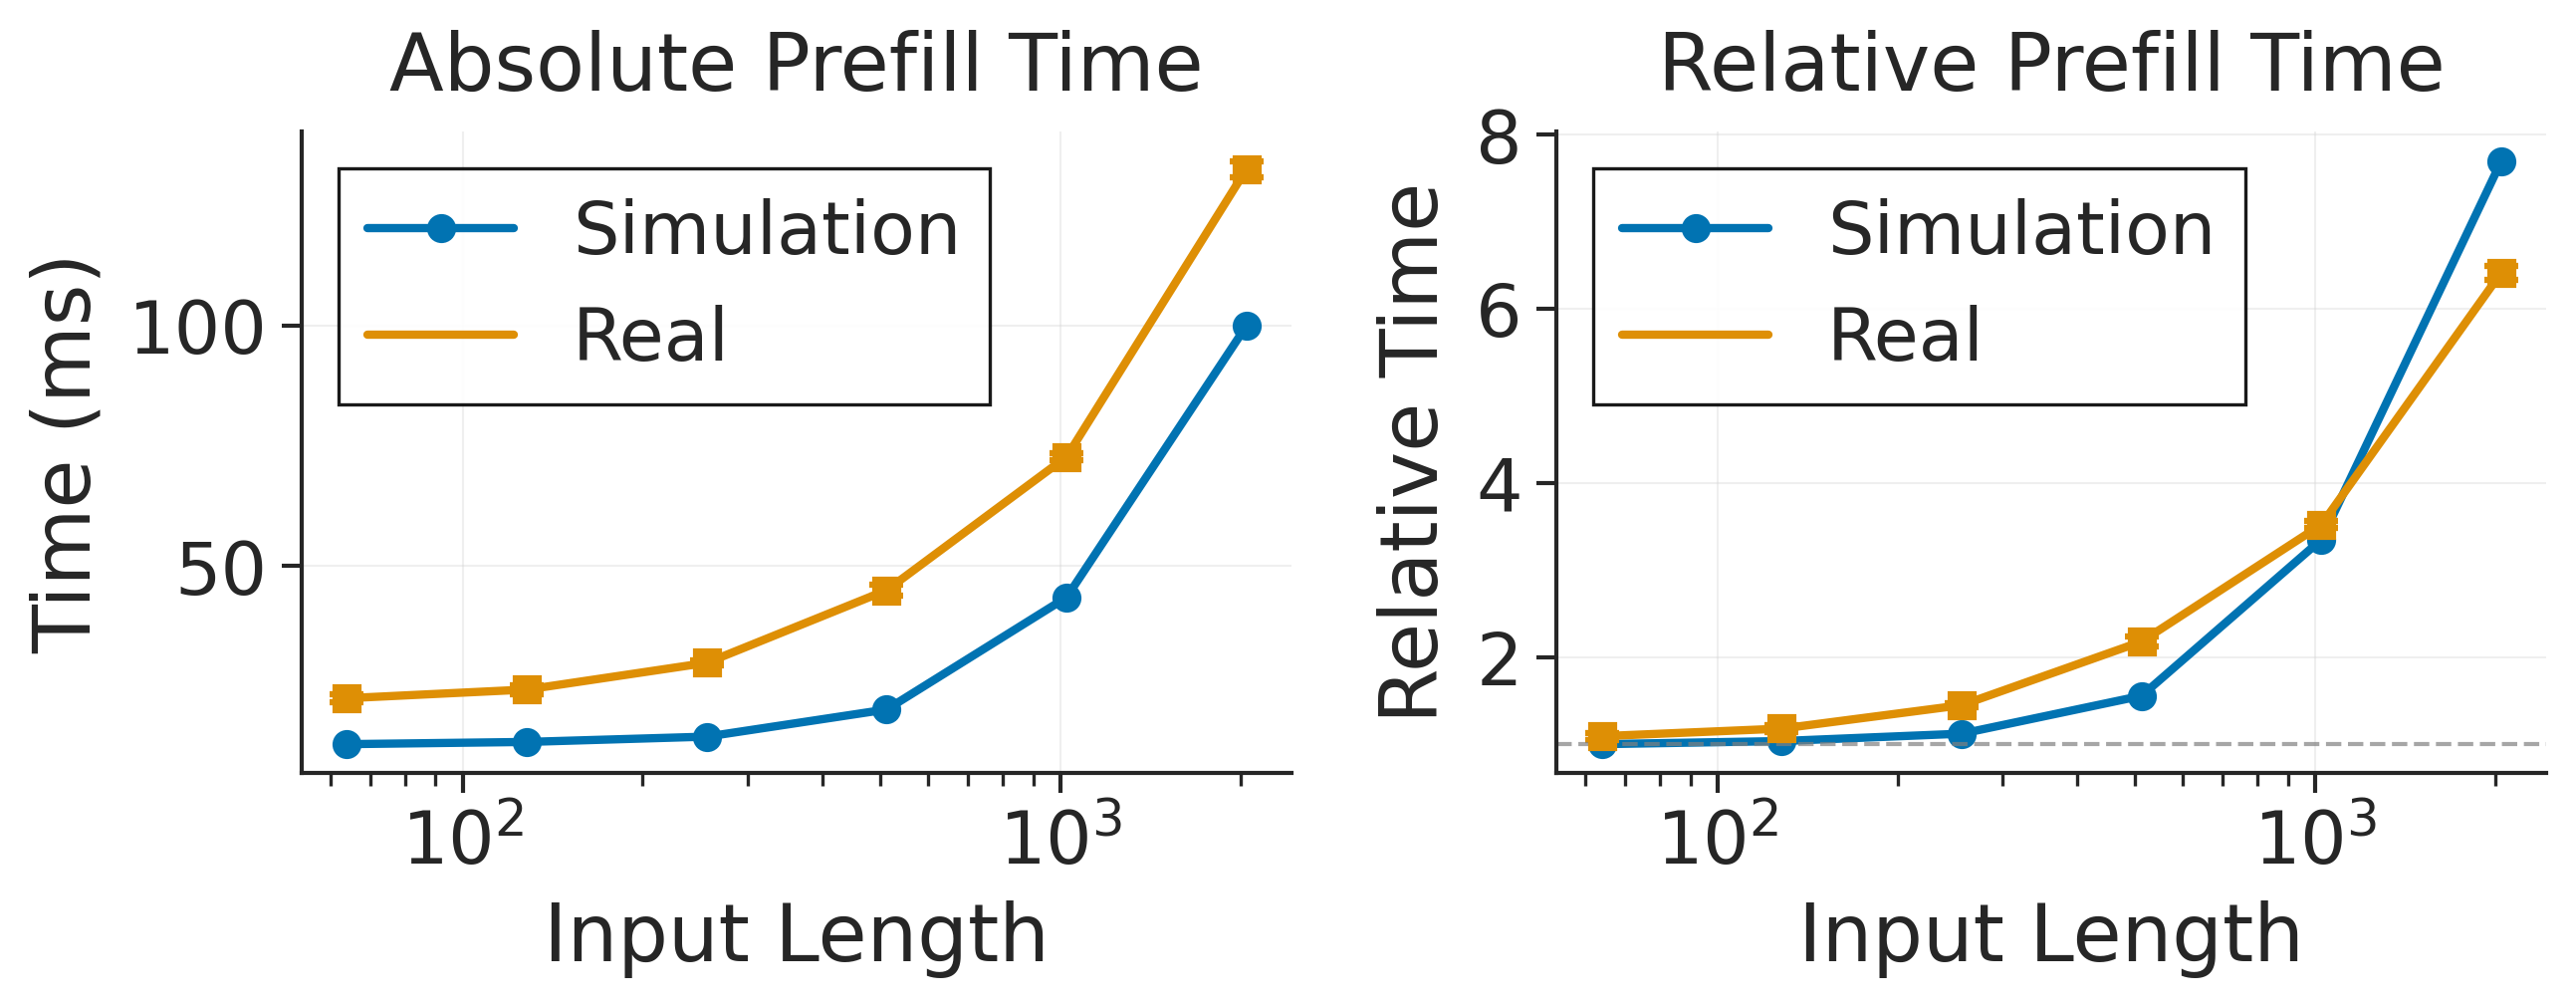

Saved figure: figures/prefill_time_comparison.pdf


In [ ]:
# plot 1: Absolute value vs. relative to baseline
llama_2_13b_df = df[df['model_id']=='meta-llama/Llama-2-13b-hf']
plot_1df = llama_2_13b_df[llama_2_13b_df['input_length']>1]
bsz_1_df = plot_1df[plot_1df['batch_size']==1]

sim_df = bsz_1_df[bsz_1_df['source']=='simulation']
real_df = bsz_1_df[bsz_1_df['source']=='real']

sim_baseline_time = sim_df[(sim_df['input_length'] == 64) & (sim_df['output_length'] == 16)]['prefill_time_s'].mean()
real_baseline_time = real_df[(real_df['input_length'] == 64) & (real_df['output_length'] == 16)]['prefill_time_s'].mean()

sim_df['relative_prefill_time_s'] = sim_df['prefill_time_s'] / sim_baseline_time
real_df['relative_prefill_time_s'] = real_df['prefill_time_s'] / real_baseline_time

# Convert to milliseconds
sim_df['prefill_time_ms'] = sim_df['prefill_time_s'] * 1000
real_df['prefill_time_ms'] = real_df['prefill_time_s'] * 1000

# Calculate statistics with confidence intervals for real data
def calculate_stats_with_ci(group, confidence=0.95):
    """Calculate mean and confidence interval for a group"""
    import scipy.stats as stats
    mean = group.mean()
    if len(group) > 1:
        sem = stats.sem(group)  # Standard error of the mean
        ci = stats.t.interval(confidence, len(group)-1, loc=mean, scale=sem)
        return mean, ci[0], ci[1]
    else:
        return mean, mean, mean

# Calculate means and confidence intervals for simulation and real data
sim_stats = sim_df.groupby('input_length')['prefill_time_ms'].apply(calculate_stats_with_ci).apply(pd.Series)
sim_stats.columns = ['mean', 'ci_lower', 'ci_upper']

real_stats = real_df.groupby('input_length')['prefill_time_ms'].apply(calculate_stats_with_ci).apply(pd.Series)
real_stats.columns = ['mean', 'ci_lower', 'ci_upper']

# For relative times
sim_rel_stats = sim_df.groupby('input_length')['relative_prefill_time_s'].apply(calculate_stats_with_ci).apply(pd.Series)
sim_rel_stats.columns = ['mean', 'ci_lower', 'ci_upper']

real_rel_stats = real_df.groupby('input_length')['relative_prefill_time_s'].apply(calculate_stats_with_ci).apply(pd.Series)
real_rel_stats.columns = ['mean', 'ci_lower', 'ci_upper']

set_publication_style(font_size=10)

# Create figure with two subplots side by side
fig, (ax1, ax2) = create_figure(format_type="double_column", ncols=2, nrows=1, figsize=(9, 3.75))

# Get colors from palette
colors = apply_color_palette("colorblind", 2)

# Plot 1: Absolute prefill times (in milliseconds)
plot_line(
    x=sim_stats.index.values,
    y=sim_stats['mean'].values,
    ax=ax1,
    color=colors[0],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Simulation'
)

# Add connecting line for real data
ax1.plot(
    real_stats.index.values,
    real_stats['mean'].values,
    color=colors[1],
    linewidth=2,
    linestyle='-',
    label='Real'
)

# Add confidence intervals for real data
ax1.errorbar(
    x=real_stats.index.values,
    y=real_stats['mean'].values,
    yerr=[real_stats['mean'] - real_stats['ci_lower'], real_stats['ci_upper'] - real_stats['mean']],
    fmt='s',
    color=colors[1],
    linewidth=2,
    markersize=6,
    capsize=4,
    capthick=1.5,
    label=''  # No duplicate label
)

# Style the left subplot (absolute values)
style_axes(
    ax1,
    title="Absolute Prefill Time",
    xlabel="Input Length",
    ylabel="Time (ms)",
    grid=True,
    spine_style="default",
    legend=True
)

# Plot 2: Relative prefill times
plot_line(
    x=sim_rel_stats.index.values,
    y=sim_rel_stats['mean'].values,
    ax=ax2,
    color=colors[0],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Simulation'
)

# Add connecting line for real data (relative)
ax2.plot(
    real_rel_stats.index.values,
    real_rel_stats['mean'].values,
    color=colors[1],
    linewidth=2,
    linestyle='-',
    label='Real'
)

# Add confidence intervals for real data (relative)
ax2.errorbar(
    x=real_rel_stats.index.values,
    y=real_rel_stats['mean'].values,
    yerr=[real_rel_stats['mean'] - real_rel_stats['ci_lower'], real_rel_stats['ci_upper'] - real_rel_stats['mean']],
    fmt='s',
    color=colors[1],
    linewidth=2,
    markersize=6,
    capsize=4,
    capthick=1.5,
    label=''  # No duplicate label
)

# Add horizontal line at y=1 for relative plot (baseline)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7, linewidth=1)

# Style the right subplot (relative values)
style_axes(
    ax2,
    title="Relative Prefill Time",
    xlabel="Input Length",
    ylabel="Relative Time",
    grid=True,
    spine_style="default",
    legend=True
)

# Set x-axis to log scale if input lengths vary widely
all_input_lengths = list(sim_stats.index) + list(real_stats.index)
if max(all_input_lengths) / min(all_input_lengths) > 10:
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.tight_layout()
plt.show()
save_figure(fig, "figures/prefill_time_comparison", formats=["pdf"])

Real data statistics:
                 mean   ci_lower   ci_upper
batch_size                                 
2            9.646363   9.646363   9.646363
4           10.045853  10.045853  10.045853
8           10.706796  10.706796  10.706796
16          12.242265  12.242265  12.242265
32          15.709207  15.709207  15.709207
64          23.288332  23.288332  23.288332
128         38.010259  38.010259  38.010259
256         63.127977  63.127977  63.127977

Simulation data statistics:
                 mean   ci_lower   ci_upper
batch_size                                 
2           12.988349  12.988349  12.988349
4           13.414005  13.414005  13.414005
8           14.265317  14.265317  14.265317
16          15.967941  15.967941  15.967941
32          19.373190  19.373190  19.373190
64          26.183686  26.183686  26.183686
128         39.804680  39.804680  39.804680
256         67.046668  67.046668  67.046668


/tmp/ipykernel_1133180/279952653.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sim_df['relative_decode_time_per_token_s'] = sim_df['decode_time_per_token_s'] / sim_baseline_time
/tmp/ipykernel_1133180/279952653.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df['relative_decode_time_per_token_s'] = real_df['decode_time_per_token_s'] / real_baseline_time
/tmp/ipykernel_1133180/279952653.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

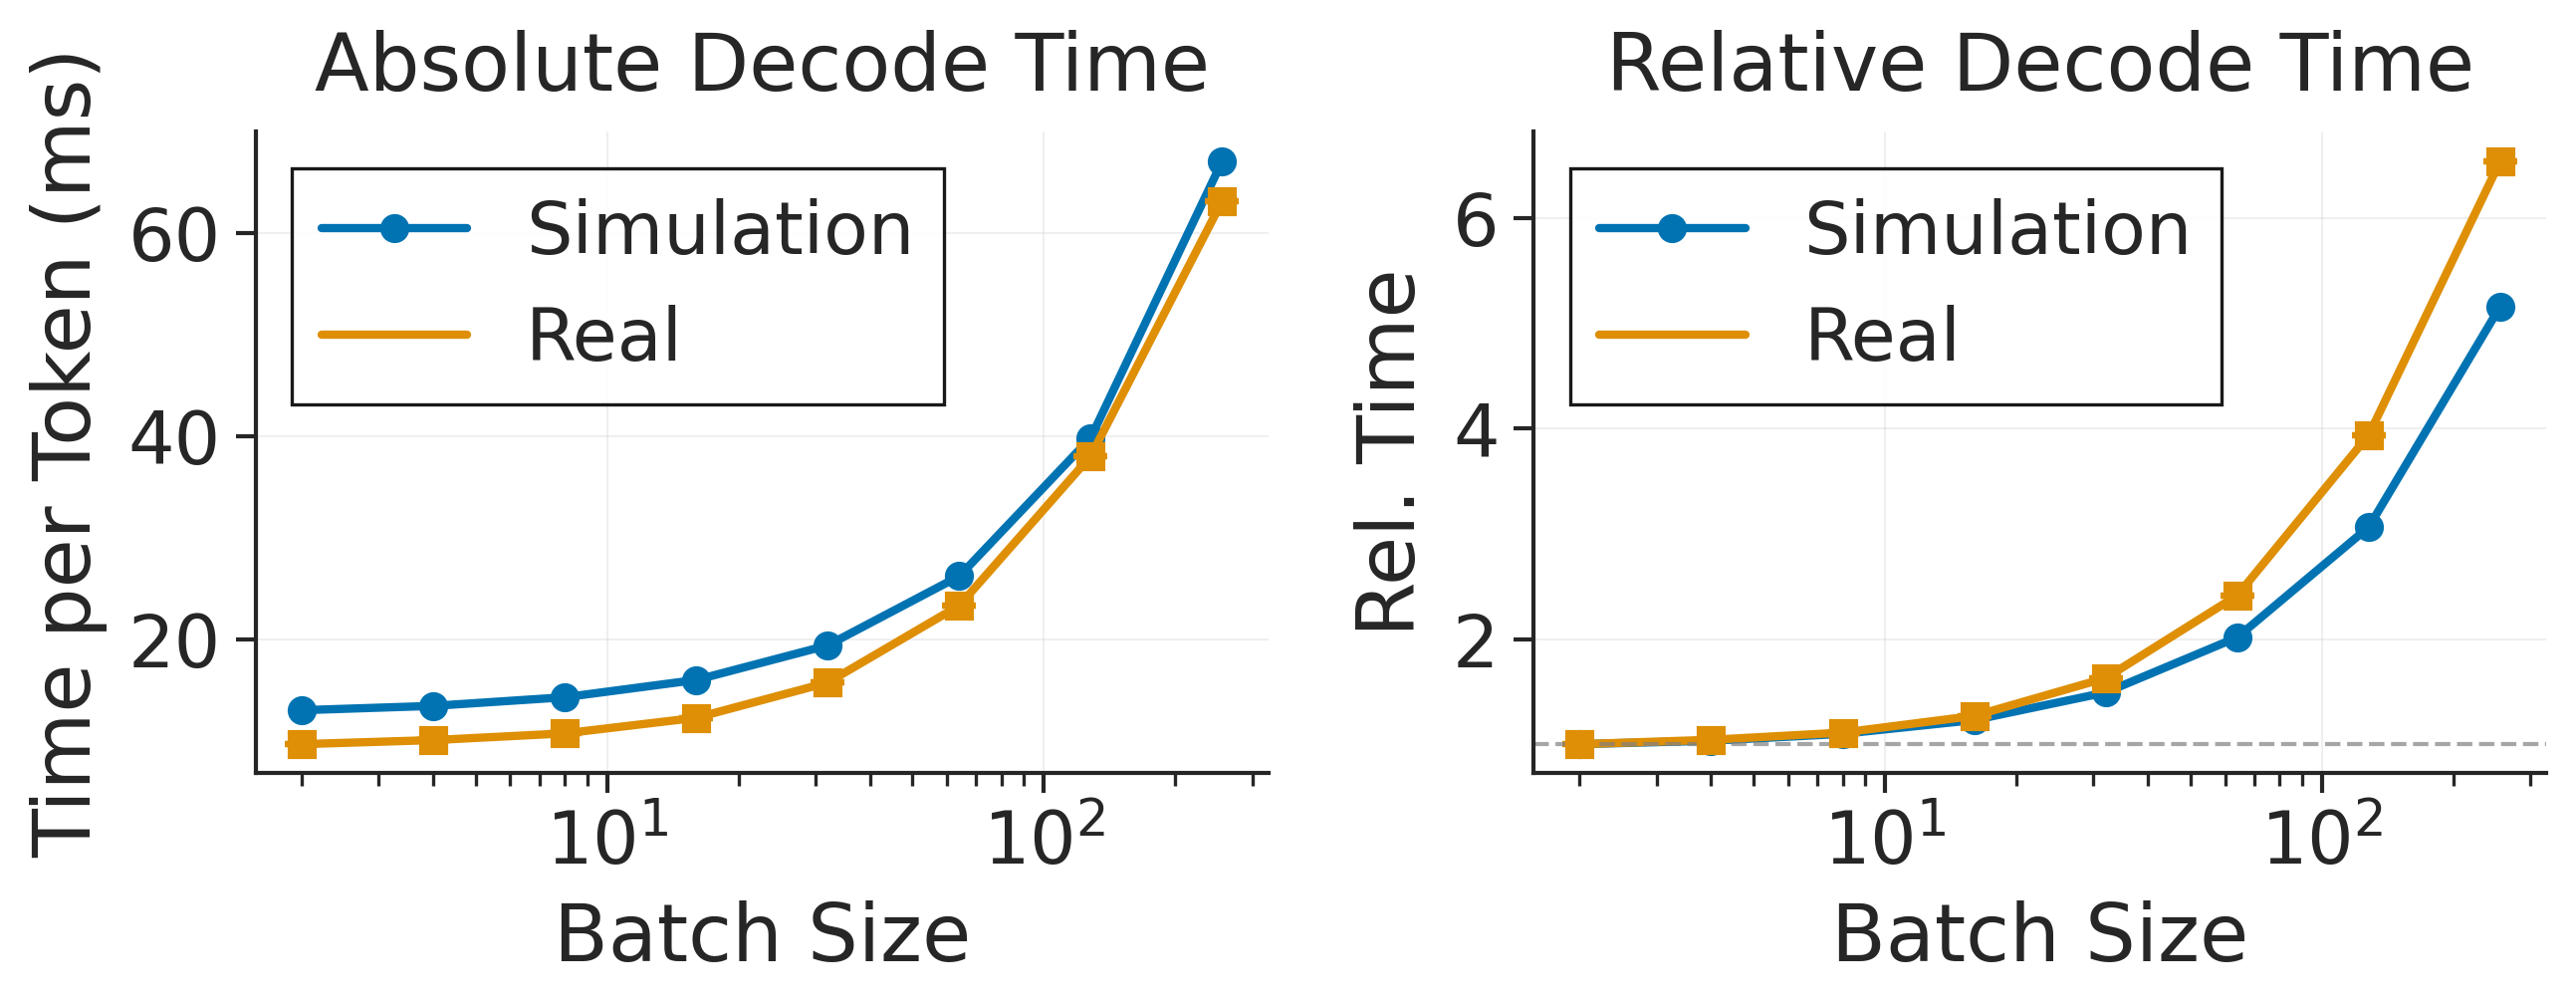

Saved figure: figures/decode_time_by_batch_size_comparison.pdf


In [4]:
# Double column figure: Absolute vs Relative Decode Times per Token by Batch Size
other_bsz_df = llama_2_13b_df[llama_2_13b_df['batch_size']>1]
sim_df = other_bsz_df[other_bsz_df['source']=='simulation']
real_df = other_bsz_df[other_bsz_df['source']=='real']

# Use batch_size=2 as baseline for relative comparison
sim_baseline_time = sim_df[(sim_df['batch_size'] == 2)]['decode_time_per_token_s'].mean()
real_baseline_time = real_df[(real_df['batch_size'] == 2)]['decode_time_per_token_s'].mean()

# Calculate relative values if not already present
if 'relative_decode_time_per_token_s' not in sim_df.columns:
    sim_df['relative_decode_time_per_token_s'] = sim_df['decode_time_per_token_s'] / sim_baseline_time
    real_df['relative_decode_time_per_token_s'] = real_df['decode_time_per_token_s'] / real_baseline_time

# add time_ms
sim_df['decode_time_per_token_ms'] = sim_df['decode_time_per_token_s'] * 1000
real_df['decode_time_per_token_ms'] = real_df['decode_time_per_token_s'] * 1000

# Calculate statistics with confidence intervals for real data
def calculate_stats_with_ci(group, confidence=0.95):
    """Calculate mean and confidence interval for a group"""
    import scipy.stats as stats
    mean = group.mean()
    if len(group) > 1:
        sem = stats.sem(group)  # Standard error of the mean
        ci = stats.t.interval(confidence, len(group)-1, loc=mean, scale=sem)
        return mean, ci[0], ci[1]
    else:
        return mean, mean, mean

# Calculate means and confidence intervals for simulation and real data
sim_stats = sim_df.groupby('batch_size')['decode_time_per_token_ms'].apply(calculate_stats_with_ci).apply(pd.Series)
sim_stats.columns = ['mean', 'ci_lower', 'ci_upper']

real_stats = real_df.groupby('batch_size')['decode_time_per_token_ms'].apply(calculate_stats_with_ci).apply(pd.Series)
real_stats.columns = ['mean', 'ci_lower', 'ci_upper']

# For relative times
sim_rel_stats = sim_df.groupby('batch_size')['relative_decode_time_per_token_s'].apply(calculate_stats_with_ci).apply(pd.Series)
sim_rel_stats.columns = ['mean', 'ci_lower', 'ci_upper']

real_rel_stats = real_df.groupby('batch_size')['relative_decode_time_per_token_s'].apply(calculate_stats_with_ci).apply(pd.Series)
real_rel_stats.columns = ['mean', 'ci_lower', 'ci_upper']

# Sort by batch_size for proper plotting
sim_stats = sim_stats.sort_index()
real_stats = real_stats.sort_index()
sim_rel_stats = sim_rel_stats.sort_index()
real_rel_stats = real_rel_stats.sort_index()

print("Real data statistics:")
print(real_stats)
print("\nSimulation data statistics:")
print(sim_stats)

set_publication_style(font_size=10)

# Create figure with two subplots side by side
fig, (ax1, ax2) = create_figure(format_type="double_column", ncols=2, nrows=1, figsize=(9, 3.75))

# Get colors from palette
colors = apply_color_palette("colorblind", 2)

# Plot 1: Absolute decode time per token (left figure)
plot_line(
    x=sim_stats.index.values,
    y=sim_stats['mean'].values,
    ax=ax1,
    color=colors[0],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Simulation'
)

# Add connecting line for real data
ax1.plot(
    real_stats.index.values,
    real_stats['mean'].values,
    color=colors[1],
    linewidth=2,
    linestyle='-',
    label='Real'
)

# Add confidence intervals for real data
ax1.errorbar(
    x=real_stats.index.values,
    y=real_stats['mean'].values,
    yerr=[real_stats['mean'] - real_stats['ci_lower'], real_stats['ci_upper'] - real_stats['mean']],
    fmt='s',
    color=colors[1],
    linewidth=2,
    markersize=6,
    capsize=4,
    capthick=1.5,
    label=''  # No duplicate label
)

# Style the left subplot (absolute values)
style_axes(
    ax1,
    title="Absolute Decode Time",
    xlabel="Batch Size",
    ylabel="Time per Token (ms)",
    grid=True,
    spine_style="default",
    legend=True
)

# Plot 2: Relative decode time per token (right figure)
plot_line(
    x=sim_rel_stats.index.values,
    y=sim_rel_stats['mean'].values,
    ax=ax2,
    color=colors[0],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Simulation'
)

# Add connecting line for real data (relative)
ax2.plot(
    real_rel_stats.index.values,
    real_rel_stats['mean'].values,
    color=colors[1],
    linewidth=2,
    linestyle='-',
    label='Real'
)

# Add confidence intervals for real data (relative)
ax2.errorbar(
    x=real_rel_stats.index.values,
    y=real_rel_stats['mean'].values,
    yerr=[real_rel_stats['mean'] - real_rel_stats['ci_lower'], real_rel_stats['ci_upper'] - real_rel_stats['mean']],
    fmt='s',
    color=colors[1],
    linewidth=2,
    markersize=6,
    capsize=4,
    capthick=1.5,
    label=''  # No duplicate label
)

# Add horizontal line at y=1 for relative plot (baseline)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7, linewidth=1)

# Style the right subplot (relative values)
style_axes(
    ax2,
    title="Relative Decode Time",
    xlabel="Batch Size",
    ylabel="Rel. Time",
    grid=True,
    spine_style="default",
    legend=True
)

# Set x-axis to log scale if batch sizes vary widely
all_batch_sizes = list(sim_stats.index) + list(real_stats.index)
if max(all_batch_sizes) / min(all_batch_sizes) > 10:
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.tight_layout()
plt.show()
save_figure(fig, "figures/decode_time_by_batch_size_comparison", formats=["pdf"])

In [5]:
def calculate_total_time(df_row):
    """Calculate total time: prefill_time_s + decode_time_per_token_s * output_length"""
    return df_row['prefill_time_s'] + df_row['decode_time_per_token_s'] * df_row['output_length']

# Get the data we have
h100_real_7b = df[(df['hw_name'] == 'NVDA:H100:NVL') & 
                  (df['model_id'] == 'meta-llama/Llama-2-7b-hf') & 
                  (df['source'] == 'real')]

rtx3090_real_7b = df[(df['hw_name'] == 'NVDA:RTX3090:PCIe') & 
                     (df['model_id'] == 'meta-llama/Llama-2-7b-hf') & 
                     (df['source'] == 'real') &
                     (df['tp_size']== 1)]

h100_sim_7b = df[(df['hw_name'] == 'NVDA:H100:NVL') & 
                  (df['model_id'] == 'meta-llama/Llama-2-7b-hf') & 
                  (df['source'] == 'simulation')]

rtx3090_sim_7b = df[(df['hw_name'] == 'NVDA:RTX3090:PCIe') & 
                     (df['model_id'] == 'meta-llama/Llama-2-7b-hf') & 
                     (df['source'] == 'simulation') &
                     (df['tp_size']== 1)]

# Find common settings across all available datasets
h100_real_settings = set(tuple(x) for x in h100_real_7b[['input_length', 'output_length', 'batch_size']].values)
rtx3090_real_settings = set(tuple(x) for x in rtx3090_real_7b[['input_length', 'output_length', 'batch_size']].values)
h100_sim_settings = set(tuple(x) for x in h100_sim_7b[['input_length', 'output_length', 'batch_size']].values)
rtx3090_sim_settings = set(tuple(x) for x in rtx3090_sim_7b[['input_length', 'output_length', 'batch_size']].values)
common_settings = h100_real_settings & rtx3090_real_settings & h100_sim_settings & rtx3090_sim_settings
# Filter datasets to only include common settings
print(f"Number of common settings: {len(common_settings)}")
# form a DataFrame to have common settings
common_settings_df = pd.DataFrame(list(common_settings), columns=['input_length', 'output_length', 'batch_size'])
h100_real_7b = pd.merge(h100_real_7b, common_settings_df, on=['input_length', 'output_length', 'batch_size'])
rtx3090_real_7b = pd.merge(rtx3090_real_7b
, common_settings_df, on=['input_length', 'output_length', 'batch_size'])
h100_sim_7b = pd.merge(h100_sim_7b, common_settings_df, on=['input_length', 'output_length', 'batch_size'])
rtx3090_sim_7b = pd.merge(rtx3090_sim_7b, common_settings_df, on=['input_length', 'output_length', 'batch_size'])
# Calculate total times
h100_real_7b['total_time_s'] = h100_real_7b.apply(calculate_total_time, axis=1)
rtx3090_real_7b['total_time_s'] = rtx3090_real_7b.apply(calculate_total_time, axis=1)
h100_sim_7b['total_time_s'] = h100_sim_7b.apply(calculate_total_time, axis=1)
rtx3090_sim_7b['total_time_s'] = rtx3090_sim_7b.apply(calculate_total_time, axis=1)
# Create a summary DataFrame for plotting

hetero_plot_df = pd.DataFrame({
    'h100_real': h100_real_7b.groupby(['input_length', 'output_length', 'batch_size'])['total_time_s'].mean(),
    'rtx3090_real': rtx3090_real_7b.groupby(['input_length', 'output_length', 'batch_size'])['total_time_s'].mean(),
    'h100_sim': h100_sim_7b.groupby(['input_length', 'output_length', 'batch_size'])['total_time_s'].mean(),
    'rtx3090_sim': rtx3090_sim_7b.groupby(['input_length', 'output_length', 'batch_size'])['total_time_s'].mean(),
}).reset_index()

Number of common settings: 6


/tmp/ipykernel_1133180/739829260.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


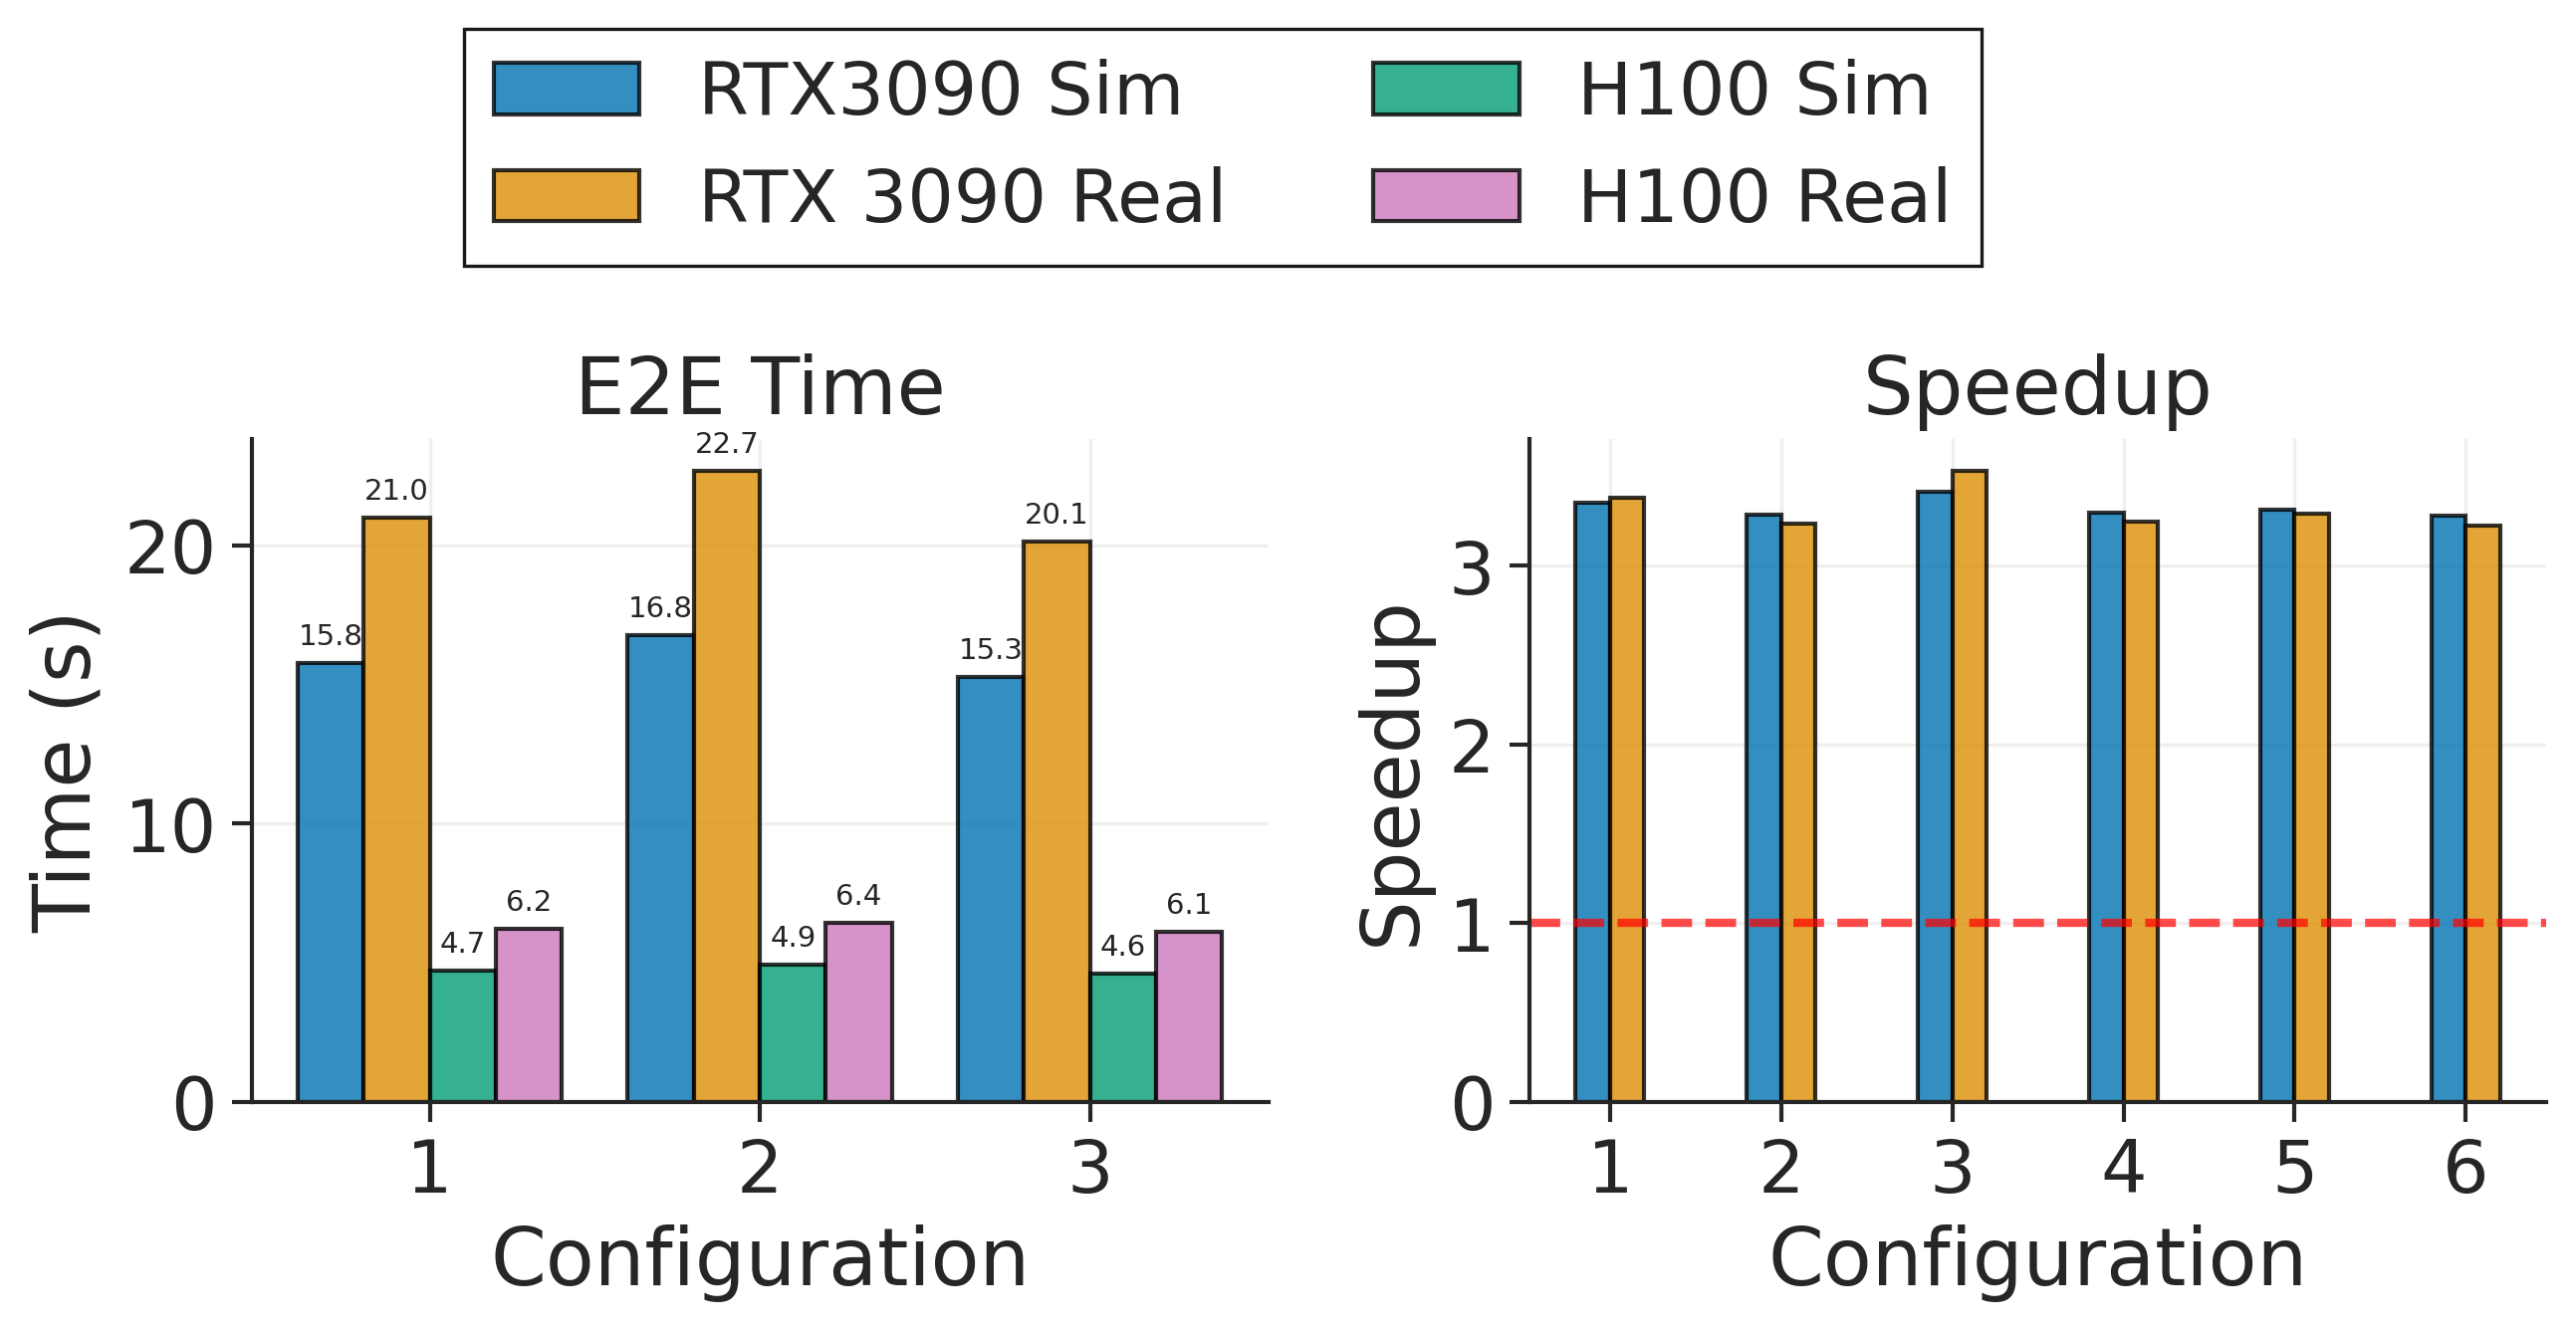

Saved figure: figures/h100_rtx3090_four_bar_comparison.pdf


In [6]:
set_publication_style(font_size=10)
fig, (ax1, ax2) = create_figure(format_type="double_column", ncols=2, nrows=1, figsize=(9, 3.75))

# Get colors from palette (need 4 colors for 4 bars)
colors = apply_color_palette("colorblind", 4)

# Create configuration labels from hetero_plot_df
hetero_plot_df['config'] = hetero_plot_df.apply(
    lambda row: f"IL{row['input_length']}_OL{row['output_length']}_BS{row['batch_size']}", 
    axis=1
)

# Get all 6 unique configurations for x-axis labels (sorted by input_length)
configs = sorted(hetero_plot_df['config'].unique())
x = np.arange(len(configs))
width = 0.2  # Narrower width to fit 4 bars

# Plot 1: Four bars comparison (left figure) - keep as is with first 3 configs
display_configs = configs[::2]  # Take first 3 configurations for display
display_x = np.arange(len(display_configs))

# Filter hetero_plot_df to only include the configurations we're displaying
plot_data = hetero_plot_df[hetero_plot_df['config'].isin(display_configs)].copy()

# Plot 1: Four bars comparison (left figure)
h100_real_vals = [plot_data[plot_data['config'] == config]['h100_real'].iloc[0] for config in display_configs]
rtx3090_real_vals = [plot_data[plot_data['config'] == config]['rtx3090_real'].iloc[0] for config in display_configs]
h100_sim_vals = [plot_data[plot_data['config'] == config]['h100_sim'].iloc[0] for config in display_configs]
rtx3090_sim_vals = [plot_data[plot_data['config'] == config]['rtx3090_sim'].iloc[0] for config in display_configs]

p1 = ax1.bar(
    display_x - 1.5*width,
    rtx3090_sim_vals,
    width,
    label="RTX 3090 Sim",
    color=colors[0],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

p2 = ax1.bar(
    display_x - 0.5*width,
    rtx3090_real_vals,
    width,
    label="RTX 3090 Real",
    color=colors[1],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

p3 = ax1.bar(
    display_x + 0.5*width,
    h100_sim_vals,
    width,
    label="H100 Sim",
    color=colors[2],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

p4 = ax1.bar(
    display_x + 1.5*width,
    h100_real_vals,
    width,
    label="H100 Real",
    color=colors[3],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

# Style the left subplot
ax1.set_xlabel('Configuration')
ax1.set_ylabel('Time (s)')
ax1.set_title('E2E Time')
ax1.set_xticks(display_x)
ax1.set_xticklabels(["1", "2", "3"])
ax1.grid(True, alpha=0.3)

# Add value labels on bars
def add_value_labels(bars, ax, fmt='{:.2f}'):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):  # Only add labels for non-NaN values
            ax.annotate(fmt.format(height),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=7
                    )

add_value_labels(p1, ax1, '{:.1f}')
add_value_labels(p2, ax1, '{:.1f}')
add_value_labels(p3, ax1, '{:.1f}')
add_value_labels(p4, ax1, '{:.1f}')

# Plot 2: 6 groups of bars - Simulated vs Real speedup (right figure)
# Calculate speedup ratios for all 6 configurations
all_h100_real_vals = [hetero_plot_df[hetero_plot_df['config'] == config]['h100_real'].iloc[0] for config in configs]
all_rtx3090_real_vals = [hetero_plot_df[hetero_plot_df['config'] == config]['rtx3090_real'].iloc[0] for config in configs]
all_h100_sim_vals = [hetero_plot_df[hetero_plot_df['config'] == config]['h100_sim'].iloc[0] for config in configs]
all_rtx3090_sim_vals = [hetero_plot_df[hetero_plot_df['config'] == config]['rtx3090_sim'].iloc[0] for config in configs]

# Calculate speedups: RTX3090/H100 (higher means H100 is faster)
real_speedups = np.array(all_rtx3090_real_vals) / np.array(all_h100_real_vals)
sim_speedups = np.array(all_rtx3090_sim_vals) / np.array(all_h100_sim_vals)

# Create 6 groups of bars with 2 bars each
p5 = ax2.bar(
    x - width/2,
    sim_speedups,
    width,
    label="Simulated Speedup (RTX3090/H100)",
    color=colors[0],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

p6 = ax2.bar(
    x + width/2,
    real_speedups,
    width,
    label="Real Speedup",
    color=colors[1],
    alpha=0.8,
    linewidth=1,
    edgecolor="k",
)

# Add horizontal line at y=1 (baseline)
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Baseline')

# Style the right subplot
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Speedup')
ax2.set_title('Speedup')
ax2.set_xticks(x)
ax2.set_xticklabels(["1", "2", "3", "4", "5", "6"])  # Extract input lengths
ax2.grid(True, alpha=0.3)

# Add value labels for speedups

# Create a single legend for both subplots
all_handles = [p1[0], p2[0], p3[0], p4[0], p5[0], p6[0]]
all_labels = ["RTX3090 Sim", "RTX 3090 Real", "H100 Sim", "H100 Real", "Sim Speedup", "Real Speedup"]

# Add baseline line to legend
from matplotlib.lines import Line2D
baseline_line = Line2D([0], [0], color='red', linestyle='--', alpha=0.7, linewidth=2, label='Baseline')
all_handles.append(baseline_line)
all_labels.append('Baseline')

fig.legend(
    handles=all_handles[:4],  # Only show first 4 (the bars) for cleaner legend
    labels=all_labels[:4],
    ncols=2,
    bbox_to_anchor=(0.18, 1.245),
    loc=2,
)

sns.despine()
plt.tight_layout()
plt.show()
save_figure(fig, "figures/h100_rtx3090_four_bar_comparison", formats=["pdf"])